In [1]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
from skimage.feature import graycomatrix, graycoprops

In [ ]:
path = r'Picture6.jpg'

img_array = np.fromfile(path, dtype=np.uint8)
img = cv2.imdecode(img_array,  cv2.IMREAD_COLOR_RGB)
img_greyscale = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

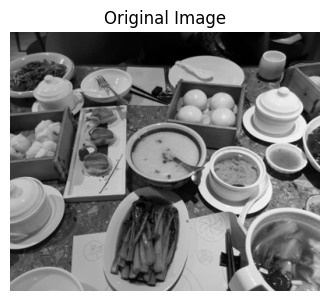

In [55]:
plt.figure(figsize=(4, 4))
plt.imshow(img_greyscale, cmap='gray', vmin=0, vmax=255)
plt.title("Original Image")
plt.axis('off')
plt.show()

In [68]:
img_greyscale.shape

(333, 398)

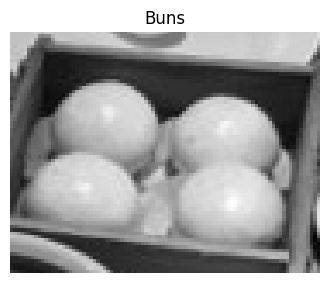

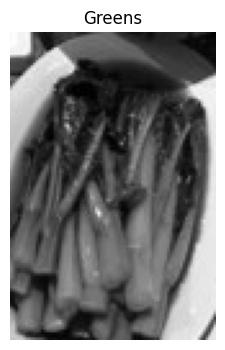

In [ ]:
arr = np.array(img_greyscale)

buns  = arr[60:130, 210:300]  
greens = arr[200:320, 140:220] 

plt.figure(figsize=(4,4))
plt.imshow(buns, cmap='gray')
plt.title("Buns")
plt.axis('off')
plt.show()


plt.figure(figsize=(4,4))
plt.imshow(greens, cmap='gray')
plt.title("Greens")
plt.axis('off')
plt.show()

### Haralick

In [92]:
img_greyscale = greens

win = 7
pad = win // 2
h, w = img_greyscale.shape

# outputs
energy_map      = np.zeros_like(img_greyscale, dtype=float)
entropy_map     = np.zeros_like(img_greyscale, dtype=float)
contrast_map    = np.zeros_like(img_greyscale, dtype=float)
homog_map       = np.zeros_like(img_greyscale, dtype=float)
correlation_map = np.zeros_like(img_greyscale, dtype=float)

padded = np.pad(img_greyscale, pad, mode='reflect')

In [93]:
def compute_entropy(glcm):
    """Entropy = -sum(p*log(p))"""
    p = glcm.astype(float)
    p = p / (p.sum() + 1e-12)
    return -(p * np.log(p + 1e-12)).sum()

In [94]:
for i in range(h):
    for j in range(w):
        patch = padded[i:i+win, j:j+win]

        glcm = graycomatrix(patch, distances=[1], angles=[0], 
                            levels=256, symmetric=True, normed=True)
        
        energy      = graycoprops(glcm, 'energy')[0, 0]
        homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]
        correlation = graycoprops(glcm, 'correlation')[0, 0]
        contrast    = graycoprops(glcm, 'contrast')[0, 0]
        entropy_val = compute_entropy(glcm[:, :, 0, 0])   

        energy_map[i, j]      = energy
        homog_map[i, j]       = homogeneity
        correlation_map[i, j] = correlation
        entropy_map[i, j]     = entropy_val
        contrast_map[i, j]    = contrast


In [95]:
from scipy.stats import skew, kurtosis, entropy

def image_statistics(img):
    img_flat = img.flatten()

    mean_val = np.mean(img_flat)
    std_val = np.std(img_flat)

    skew_val = skew(img_flat, bias=False)
    kurt_val = kurtosis(img_flat, bias=False)
 

    hist = np.histogram(img_flat, bins=256, range=(0, 256))[0] + 1
    entropy_val = entropy(hist)

    return mean_val, std_val, skew_val, kurt_val, entropy_val


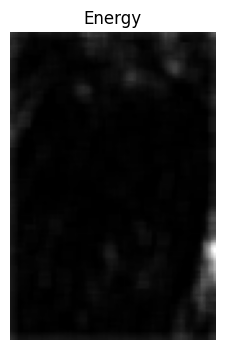

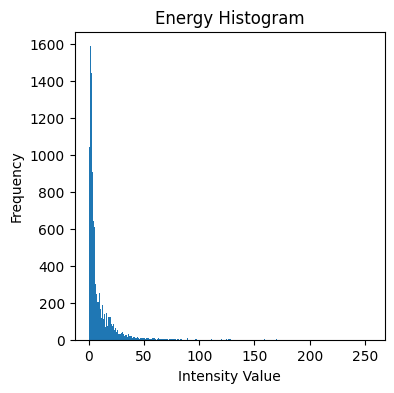

Mean: 8.5009375, Std: 16.045910666618262, Skewness: 6.334271827735696, Kurtosis: 62.077934107113904, Entropy: 3.172393885900569


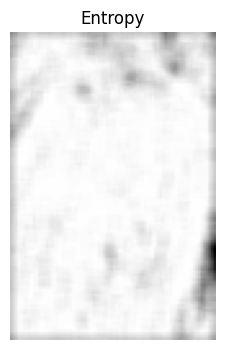

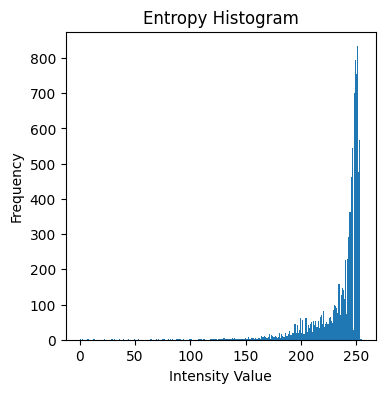

Mean: 237.0534375, Std: 24.163659841456006, Skewness: -3.303622791539886, Kurtosis: 16.80508599205093, Entropy: 3.8002558738694234


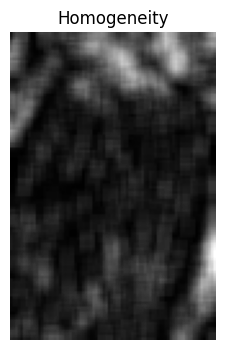

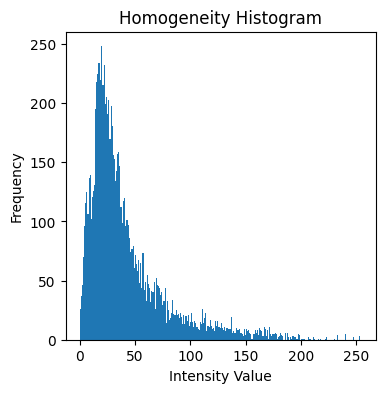

Mean: 42.18375, Std: 37.31416993052595, Skewness: 1.9346141177232417, Kurtosis: 4.214403204792243, Entropy: 4.693224280756949


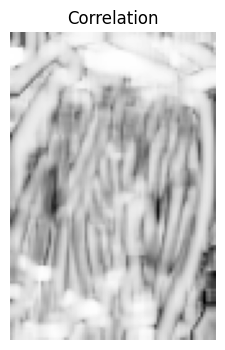

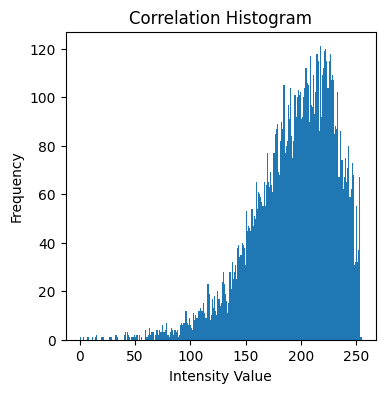

Mean: 194.46677083333333, Std: 38.08225937567014, Skewness: -0.9540404471504181, Kurtosis: 1.2193927739772095, Entropy: 4.981383255376504


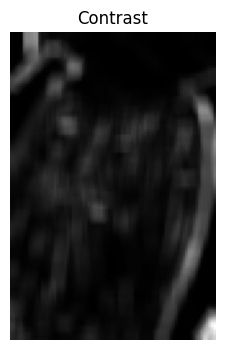

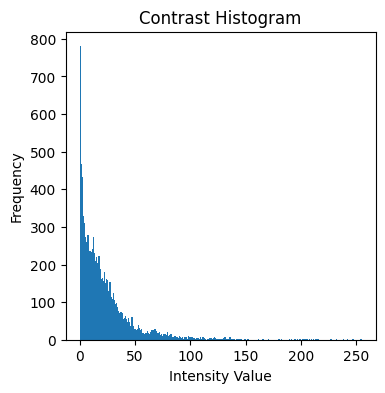

Mean: 21.918125, Std: 25.827524171273335, Skewness: 2.839658330274441, Kurtosis: 12.797074336629365, Entropy: 4.164543698116024


In [96]:
def normalize(img):
    return cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

energy_vis      = normalize(energy_map)
entropy_vis     = normalize(entropy_map)
homog_vis       = normalize(homog_map)
corr_vis        = normalize(correlation_map)
contrast_vis    = normalize(contrast_map)

plt.figure(figsize=(4, 4))
plt.imshow(energy_vis, cmap='gray')
plt.title("Energy")
plt.axis('off')
plt.show()

plt.figure(figsize=(4, 4))
plt.hist(energy_vis.ravel(), bins=256, range=(0, 255))
plt.title("Energy Histogram")
plt.xlabel("Intensity Value")
plt.ylabel("Frequency")
plt.show()

mean, std, skew1, kurt1, entropy1 = image_statistics(energy_vis)
print(f"Mean: {mean}, Std: {std}, Skewness: {skew1}, Kurtosis: {kurt1}, Entropy: {entropy1}")

plt.figure(figsize=(4, 4))
plt.imshow(entropy_vis, cmap='gray')
plt.title("Entropy")
plt.axis('off')
plt.show()

plt.figure(figsize=(4, 4))
plt.hist(entropy_vis.ravel(), bins=256, range=(0, 255))
plt.title("Entropy Histogram")
plt.xlabel("Intensity Value")
plt.ylabel("Frequency")
plt.show()

mean, std, skew1, kurt1, entropy1 = image_statistics(entropy_vis)
print(f"Mean: {mean}, Std: {std}, Skewness: {skew1}, Kurtosis: {kurt1}, Entropy: {entropy1}")

plt.figure(figsize=(4, 4))
plt.imshow(homog_vis, cmap='gray')
plt.title("Homogeneity")
plt.axis('off')
plt.show()

plt.figure(figsize=(4, 4))
plt.hist(homog_vis.ravel(), bins=256, range=(0, 255))
plt.title("Homogeneity Histogram")
plt.xlabel("Intensity Value")
plt.ylabel("Frequency")
plt.show()

mean, std, skew1, kurt1, entropy1 = image_statistics(homog_vis)
print(f"Mean: {mean}, Std: {std}, Skewness: {skew1}, Kurtosis: {kurt1}, Entropy: {entropy1}")

plt.figure(figsize=(4, 4))
plt.imshow(corr_vis, cmap='gray')
plt.title("Correlation")
plt.axis('off')
plt.show()

plt.figure(figsize=(4, 4))
plt.hist(corr_vis.ravel(), bins=256, range=(0, 255))
plt.title("Correlation Histogram")
plt.xlabel("Intensity Value")
plt.ylabel("Frequency")
plt.show()

mean, std, skew1, kurt1, entropy1 = image_statistics(corr_vis)
print(f"Mean: {mean}, Std: {std}, Skewness: {skew1}, Kurtosis: {kurt1}, Entropy: {entropy1}")

plt.figure(figsize=(4, 4))
plt.imshow(contrast_vis, cmap='gray')
plt.title("Contrast")
plt.axis('off')
plt.show()

plt.figure(figsize=(4, 4))
plt.hist(contrast_vis.ravel(), bins=256, range=(0, 255))
plt.title("Contrast Histogram")
plt.xlabel("Intensity Value")
plt.ylabel("Frequency")
plt.show()

mean, std, skew1, kurt1, entropy1 = image_statistics(contrast_vis)
print(f"Mean: {mean}, Std: {std}, Skewness: {skew1}, Kurtosis: {kurt1}, Entropy: {entropy1}")

## Haralick with LBP

In [97]:
def local_binary_pattern(img, kernel_size):
    h, w = img.shape
    pad = kernel_size // 2
    padded_img = np.pad(img, pad, mode='edge')
    img_new = np.zeros((h, w), dtype=float)

    # Center index for any kernel size
    center_idx = (kernel_size * kernel_size) // 2

    for i in range(h):
        for j in range(w):
            window = padded_img[i:i+kernel_size, j:j+kernel_size].flatten()
            center_pixel = window[center_idx]

            # Compare neighbors 
            binary = (window >= center_pixel).astype(int)

            binary = np.delete(binary, center_idx)

            # Build number with binary weights
            lbp_value = 0
            for k in range(len(binary)):
                lbp_value += binary[k] * (2 ** k) # formula

            img_new[i, j] = lbp_value

    return img_new

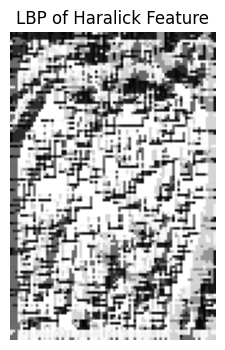

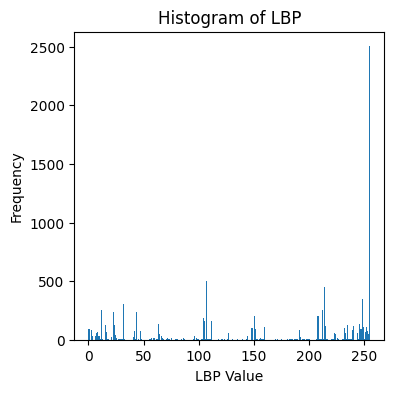

Mean: 165.99760416666666, Std: 92.74074355477919, Skewness: -0.5393628649433454, Kurtosis: -1.3260314051929458, Entropy: 3.6684033603560358


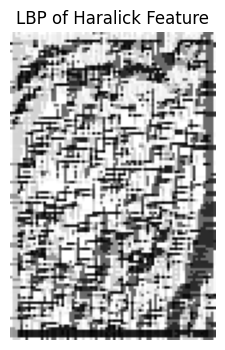

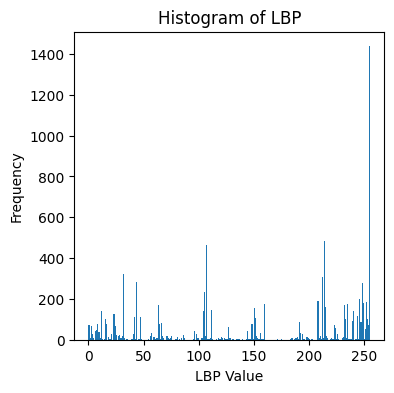

Mean: 158.26104166666667, Std: 90.25316928275481, Skewness: -0.40360744817835315, Kurtosis: -1.4263307575448512, Entropy: 4.106950225739483


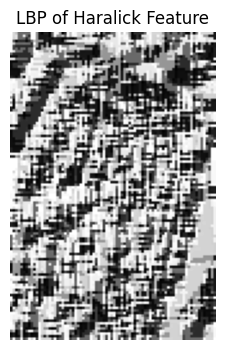

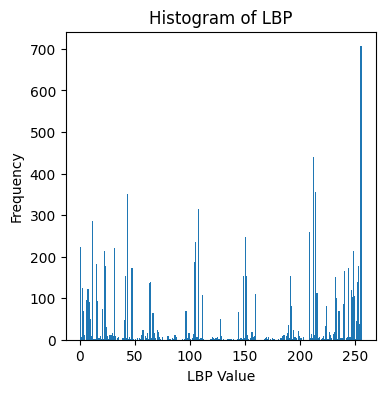

Mean: 137.20166666666665, Std: 92.86769238485948, Skewness: -0.12598806168687948, Kurtosis: -1.5835631671152144, Entropy: 4.273195930599802


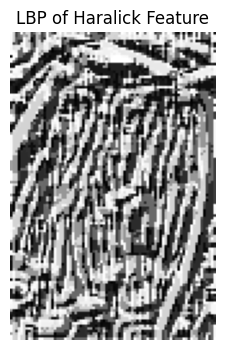

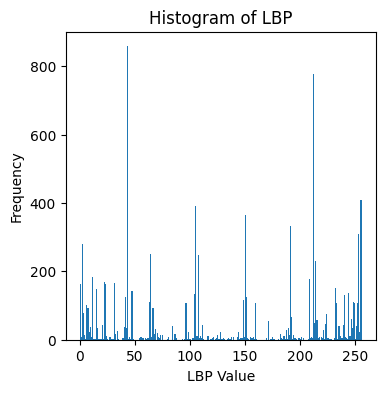

Mean: 131.2028125, Std: 88.97385742222176, Skewness: -0.027001339025459647, Kurtosis: -1.5489038635971397, Entropy: 4.1528825639039635


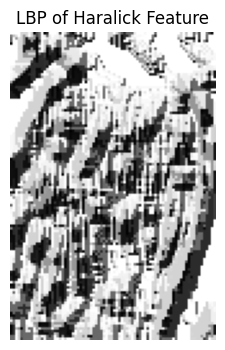

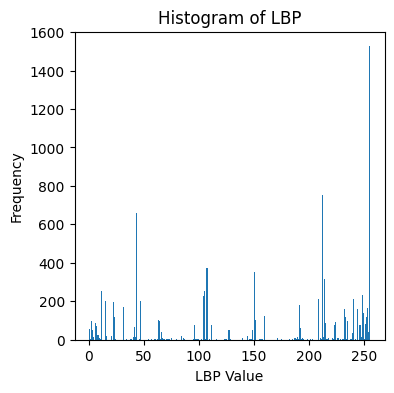

Mean: 156.60302083333335, Std: 90.87498057794143, Skewness: -0.40650945704027025, Kurtosis: -1.428458901187982, Entropy: 3.7877877419022123


In [98]:
haralick_imgs = [energy_vis, entropy_vis, homog_vis, corr_vis, contrast_vis]

for img in haralick_imgs:
    lbp_img = local_binary_pattern(img=img, kernel_size=3)
    plt.figure(figsize=(4, 4))
    plt.imshow(lbp_img, cmap='gray')
    plt.title("LBP of Haralick Feature")
    plt.axis('off')
    plt.show()

    plt.figure(figsize=(4, 4))
    plt.hist(lbp_img.ravel(), bins=256, range=(0, 256))
    plt.title("Histogram of LBP")
    plt.xlabel("LBP Value")
    plt.ylabel("Frequency")
    plt.show()

    mean, std, skew1, kurt1, entropy1 = image_statistics(lbp_img)
    print(f"Mean: {mean}, Std: {std}, Skewness: {skew1}, Kurtosis: {kurt1}, Entropy: {entropy1}")

### Box Counting

In [ ]:
path = r'tonguedataset\Non Stain\ 17.JPG'


img_array = np.fromfile(path, dtype=np.uint8)
img = cv2.imdecode(img_array,  cv2.IMREAD_COLOR_RGB)
img_greyscale = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

In [134]:
def boxed_image(img, box_size, threshold=1):

    h, w = img.shape
    output = img.copy()

    bs = box_size

    for i in range(0, h - bs + 1, bs):
        for j in range(0, w - bs + 1, bs):
            patch = img[i:i+bs, j:j+bs]
            variation = patch.max() - patch.min()

            if variation <= threshold:
                output[i:i+bs, j:j+bs] = 0
            else:
                output[i:i+bs, j:j+bs] = 255

    return output

def count_white_boxes(boxed_img, box_size):
    h, w = boxed_img.shape
    count = 0
    
    for i in range(0, h, box_size):
        for j in range(0, w, box_size):
            patch = boxed_img[i:i+box_size, j:j+box_size]
            if patch.mean() == 255:   
                count += 1
    return count


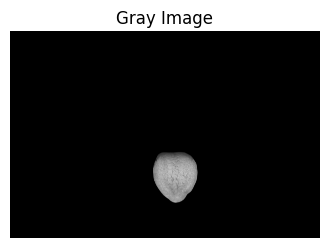

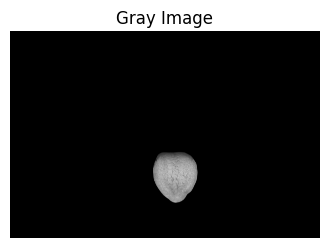

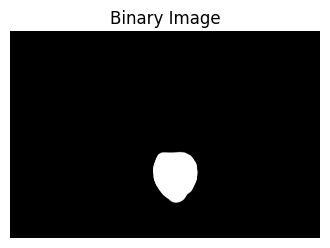

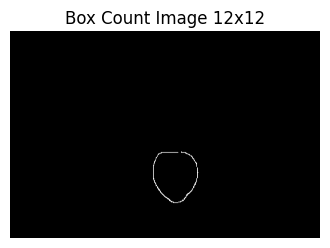

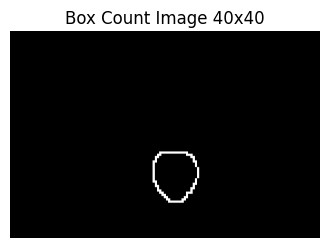

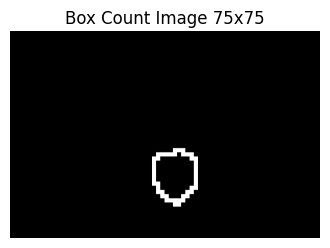

In [135]:
binary = (img_greyscale > 10).astype(np.uint8) * 255

plt.figure(figsize=(4, 4))
plt.imshow(img_greyscale, cmap="gray")
plt.title("Gray Image")
plt.axis('off')
plt.show()

plt.figure(figsize=(4, 4))
plt.imshow(img_greyscale, cmap="gray")
plt.title("Gray Image")
plt.axis('off')
plt.show()

plt.figure(figsize=(4, 4))
plt.imshow(binary, cmap="gray")
plt.title("Binary Image")
plt.axis('off')
plt.show()

num = [2, 4, 8, 12, 22, 40, 75, 128, 256]
show_num = [12, 40, 75, 125]
box_counts = []

for n in num:
    boxed = boxed_image(binary, n, n)
    count = count_white_boxes(boxed, n)
    
    box_counts.append(count)
    if n in show_num:
        plt.figure(figsize=(4, 4))
        plt.imshow(boxed, cmap="gray")
        plt.title(f"Box Count Image {n}x{n}")
        plt.axis('off')
        plt.show()

In [ ]:
box_counts = []

for n in num:
    boxed = boxed_image(binary, n, n)
    count = count_white_boxes(boxed, n)
    box_counts.append(count)


    print(f"Box size {n}x{n} → Count = {count}")


Box size 2x2 → Count = 1238
Box size 4x4 → Count = 772
Box size 8x8 → Count = 364
Box size 12x12 → Count = 282
Box size 22x22 → Count = 158
Box size 40x40 → Count = 82
Box size 75x75 → Count = 46
Box size 128x128 → Count = 28
Box size 256x256 → Count = 0


Slope (Fractal Dimension): 0.9283434031503893
Intercept: 7.864216771492472


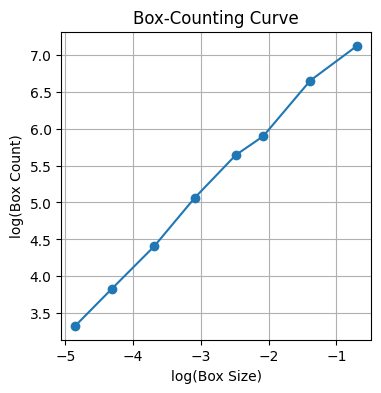

In [10]:
box_counts = np.array(box_counts)
num = np.array(num)

valid = box_counts > 0

log_sizes  = np.log((1 / num)[valid])
log_counts = np.log(box_counts[valid])

slope, intercept = np.polyfit(log_sizes, log_counts, 1)

print("Slope (Fractal Dimension):", slope)
print("Intercept:", intercept)

plt.figure(figsize=(4, 4))
plt.plot(log_sizes, log_counts, marker='o')
plt.xlabel("log(Box Size)")
plt.ylabel("log(Box Count)")
plt.title("Box-Counting Curve")
plt.grid(True)
plt.show()


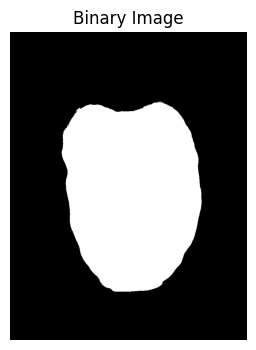

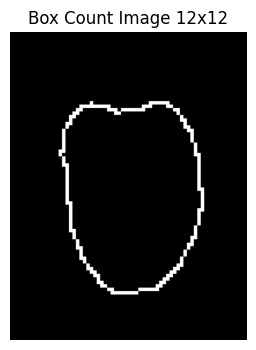

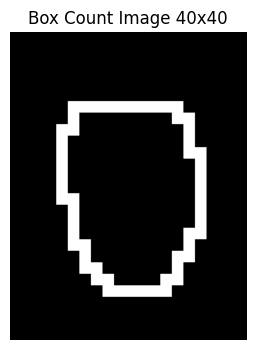

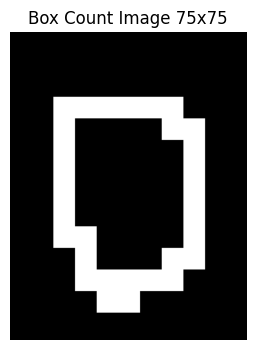

Slope (Fractal Dimension): 0.8622996075814288
Intercept: 7.23982687219296


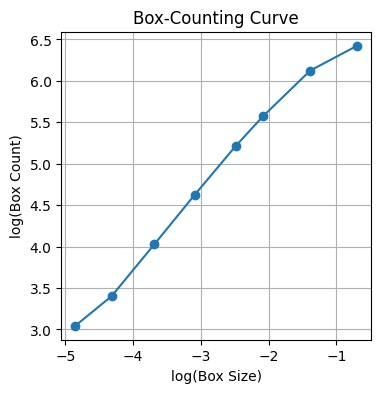

In [ ]:
path = r'\tonguedataset\Stain\8_玉米汁.JPG'

img_array = np.fromfile(path, dtype=np.uint8)
img = cv2.imdecode(img_array,  cv2.IMREAD_COLOR_RGB)
img_greyscale = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

binary = (img_greyscale > 30).astype(np.uint8) * 255

plt.figure(figsize=(4, 4))
plt.imshow(binary, cmap="gray")
plt.title("Binary Image")
plt.axis('off')
plt.show()

num = [2, 4, 8, 12, 22, 40, 75, 128, 256]
show_num = [12, 40, 75, 125]
box_counts = []

for n in num:
    boxed = boxed_image(binary, n, n)
    count = count_white_boxes(boxed, n)
    
    box_counts.append(count)
    if n in show_num:
        plt.figure(figsize=(4, 4))
        plt.imshow(boxed, cmap="gray")
        plt.title(f"Box Count Image {n}x{n}")
        plt.axis('off')
        plt.show()

box_counts = np.array(box_counts)
num = np.array(num)

valid = box_counts > 0

log_sizes  = np.log((1 / num)[valid])
log_counts = np.log(box_counts[valid])

slope, intercept = np.polyfit(log_sizes, log_counts, 1)

print("Slope (Fractal Dimension):", slope)
print("Intercept:", intercept)

plt.figure(figsize=(4, 4))
plt.plot(log_sizes, log_counts, marker='o')
plt.xlabel("log(Box Size)")
plt.ylabel("log(Box Count)")
plt.title("Box-Counting Curve")
plt.grid(True)
plt.show()


### Chain Code

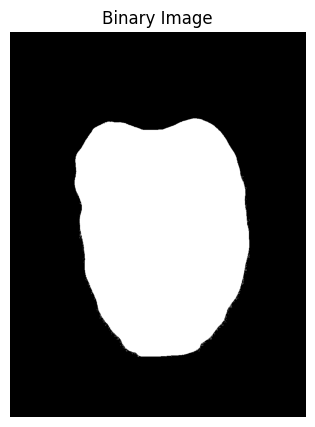

In [ ]:
path = r'C:\Users\justi\College_Stuff\tonguedataset\Stain\8_玉米汁.JPG'

img_array = np.fromfile(path, dtype=np.uint8)
img = cv2.imdecode(img_array, cv2.IMREAD_COLOR)  
grey = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

_, binary = cv2.threshold(grey, 10, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(5, 5))
plt.imshow(binary, cmap='gray')
plt.title("Binary Image")
plt.axis('off')
plt.show()

Chain code length: 2735
First 20: [6, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 6, 0, 0, 0, 0, 0, 0, 0]


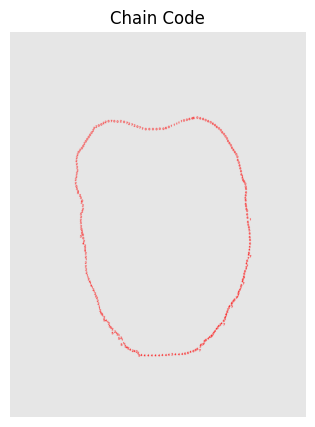

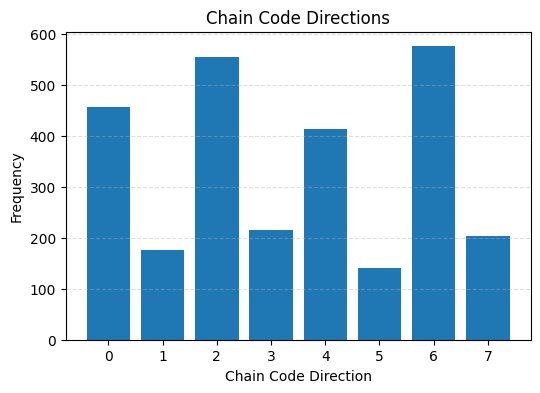

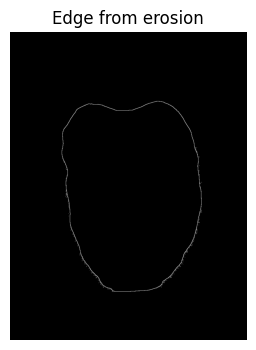

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt


#CHAIN CODE

dir_offsets = [
    (0, 1),     # 0 East
    (-1, 1),    # 1 Northeast
    (-1, 0),    # 2 North
    (-1, -1),   # 3 Northwest
    (0, -1),    # 4 West
    (1, -1),    # 5 Southwest
    (1, 0),     # 6 South
    (1, 1)      # 7 Southeast
]

vec_to_dir = {off: idx for idx, off in enumerate(dir_offsets)}



# 1. MORPHOLOGICAL BOUNDARY EXTRACTION  

kernel = np.ones((3,3), np.uint8)


eroded = cv2.erode(binary, kernel)
boundary_mask = cv2.subtract(binary, eroded)


pts_rc = np.column_stack(np.where(boundary_mask == 255))

if len(pts_rc) == 0:
    raise ValueError("No boundary found!")



# ----------------------------------------------
# 2. Force clockwise order, start at topmost
# ----------------------------------------------
# centroid
ci = np.mean(pts_rc[:, 0])
cj = np.mean(pts_rc[:, 1])

# Cartesian angle
angles = np.arctan2(-(pts_rc[:, 0] - ci), pts_rc[:, 1] - cj)


order = np.argsort(-angles)
pts_rc = pts_rc[order]


start_idx = np.argmin(pts_rc[:, 0])
pts_rc = np.roll(pts_rc, -start_idx, axis=0)



#  CHAIN CODE

chain = []
directions_at_pixels = []

for k in range(1, len(pts_rc)):
    i0, j0 = pts_rc[k-1]
    i1, j1 = pts_rc[k]

    di = i1 - i0
    dj = j1 - j0

    di_n = int(np.sign(di))
    dj_n = int(np.sign(dj))
    step_n = (di_n, dj_n)

    if step_n == (0, 0):
        continue  

    if step_n in vec_to_dir:
        d = vec_to_dir[step_n]
        chain.append(d)
        directions_at_pixels.append((i1, j1, d))

# close loop: last → first
i0, j0 = pts_rc[-1]
i1, j1 = pts_rc[0]
di_n = int(np.sign(i1 - i0))
dj_n = int(np.sign(j1 - j0))
step_n = (di_n, dj_n)

if step_n in vec_to_dir and step_n != (0,0):
    d = vec_to_dir[step_n]
    chain.append(d)
    directions_at_pixels.append((i1, j1, d))

print("Chain code length:", len(chain))
print("First 20:", chain[:20])



h, w = binary.shape
canvas = np.full((h, w, 3), 230, dtype=np.uint8)

N = 10  # show every 10th direction label
for idx, (yi, xi, d) in enumerate(directions_at_pixels):
    if idx % N == 0:
        cv2.putText(canvas, str(d), (xi, yi),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.25, (255, 0, 0), 1, cv2.LINE_AA)

plt.figure(figsize=(5, 5))
plt.imshow(canvas)
plt.title("Chain Code")
plt.axis('off')
plt.show()



# 5. FREQUENCY HISTOGRAM OF CHAIN CODE DIRECTIONS

chain_arr = np.array(chain)
unique, counts = np.unique(chain_arr, return_counts=True)

freq = np.zeros(8, dtype=int)
for u, c in zip(unique, counts):
    freq[u] = c

plt.figure(figsize=(6,4))
plt.bar(range(8), freq)
plt.xticks(range(8))
plt.xlabel("Chain Code Direction")
plt.ylabel("Frequency")
plt.title("Chain Code Directions")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()


plt.figure(figsize=(4, 4))
plt.imshow(boundary_mask, cmap='gray')
plt.title("Edge from erosion")
plt.axis('off')
plt.show()


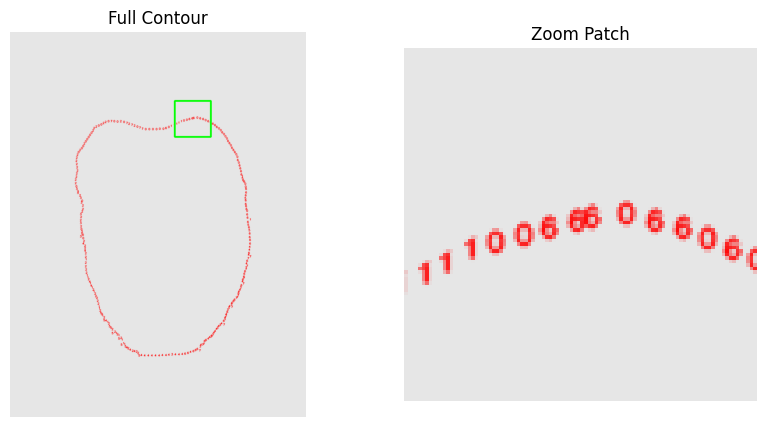

In [ ]:
def show_number_patch_with_box(canvas, directions_at_pixels, patch_radius=10, zoom_index=0):


    zoom_index = max(0, min(zoom_index, len(directions_at_pixels)-1))

    yi, xi, d = directions_at_pixels[zoom_index]

    h, w, _ = canvas.shape

    # boundaries of patch
    y1 = max(0, yi - patch_radius)
    y2 = min(h, yi + patch_radius)
    x1 = max(0, xi - patch_radius)
    x2 = min(w, xi + patch_radius)


    full_vis = canvas.copy()
    cv2.rectangle(
        full_vis,
        (x1, y1),
        (x2, y2),
        (0, 255, 0),  
        3
    )


    patch = canvas[y1:y2, x1:x2]

    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(full_vis)
    plt.title(f"Full Contour")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(patch)
    plt.title(f"Zoom Patch")
    plt.axis("off")

    plt.show()
    
show_number_patch_with_box(canvas, directions_at_pixels, patch_radius=50, zoom_index=0)


### Area

In [128]:
path = r'C:\Users\justi\College_Stuff\tonguedataset\Stain\8_玉米汁.JPG'

img_array = np.fromfile(path, dtype=np.uint8)
img = cv2.imdecode(img_array, cv2.IMREAD_COLOR)
grey = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Threshold
_, binary = cv2.threshold(grey, 10, 255, cv2.THRESH_BINARY)

# Contours
contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
cnt = max(contours, key=cv2.contourArea)

# Area & Perimeter
area = cv2.contourArea(cnt)
perimeter = cv2.arcLength(cnt, True)

print("Area:", area)
print("Perimeter:", perimeter)

hull = cv2.convexHull(cnt)

convex_area = cv2.contourArea(hull)
convex_perimeter = cv2.arcLength(hull, True)

print("Convex Area:", convex_area)
print("Convex Perimeter:", convex_perimeter)

Area: 257440.5
Perimeter: 2300.441898226738
Convex Area: 265356.0
Convex Perimeter: 1900.603003501892


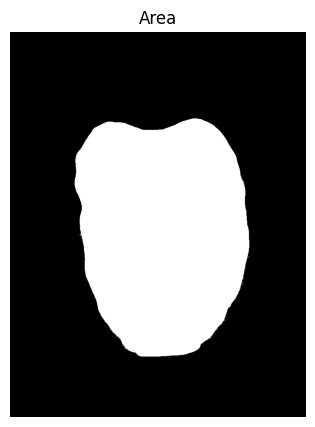

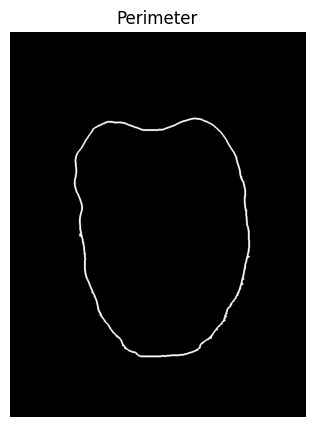

In [129]:
area_img = np.zeros_like(binary)
cv2.drawContours(area_img, [cnt], -1, 255, thickness=cv2.FILLED)     

perimeter_img = np.zeros_like(binary)
cv2.drawContours(perimeter_img, [cnt], -1, 255, thickness=3)

plt.figure(figsize=(5, 5))
plt.imshow(area_img, cmap='gray')
plt.title("Area")
plt.axis('off')
plt.show()

plt.figure(figsize=(5, 5))
plt.imshow(perimeter_img, cmap='gray')
plt.title("Perimeter")
plt.axis('off')
plt.show()

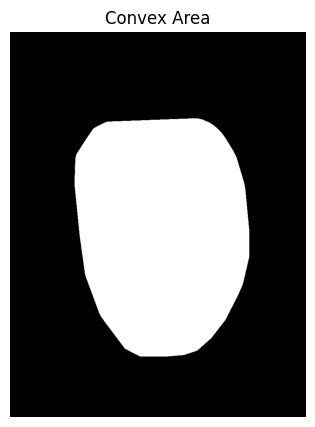

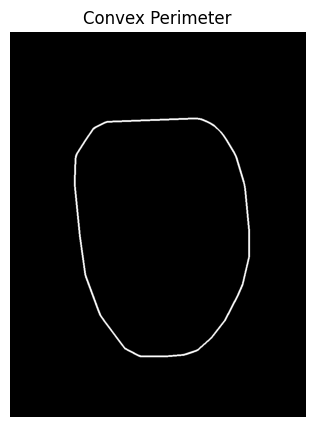

In [130]:
area_img = np.zeros_like(binary)
cv2.fillPoly(area_img, [hull], 255)

perim_img = np.zeros_like(binary)
cv2.drawContours(perim_img, [hull], -1, 255, 3)

plt.figure(figsize=(5, 5))
plt.imshow(area_img, cmap='gray')
plt.title("Convex Area")
plt.axis('off')
plt.show()

plt.figure(figsize=(5, 5))
plt.imshow(perim_img, cmap='gray')
plt.title("Convex Perimeter")
plt.axis('off')
plt.show()

### Local Binary Pattern

In [99]:
def local_binary_pattern(img, kernel_size):
    h, w = img.shape
    pad = kernel_size // 2
    padded_img = np.pad(img, pad, mode='edge')
    img_new = np.zeros((h, w), dtype=float)

    # Center index for any kernel size
    center_idx = (kernel_size * kernel_size) // 2

    for i in range(h):
        for j in range(w):
            window = padded_img[i:i+kernel_size, j:j+kernel_size].flatten()
            center_pixel = window[center_idx]

            # Compare neighbors 
            binary = (window >= center_pixel).astype(int)

            binary = np.delete(binary, center_idx)

            # Build number with binary weights
            lbp_value = 0
            for k in range(len(binary)):
                lbp_value += binary[k] * (2 ** k) # formula

            img_new[i, j] = lbp_value

    return img_new

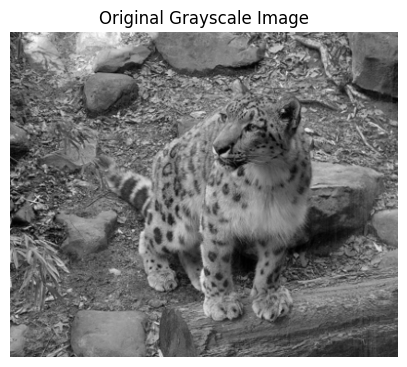

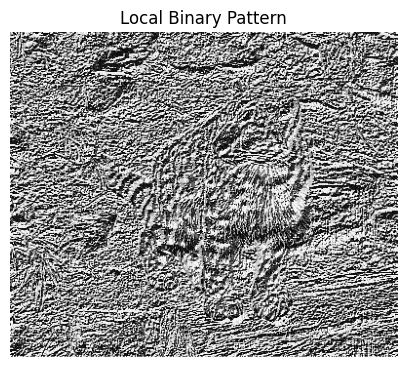

Kernel Size: 3 - Mean: 129.94252700628894, Std: 95.23467905928486, Skewness: -0.02686861094240062, Kurtosis: -1.610411353285528, Entropy: 4.732523599725075


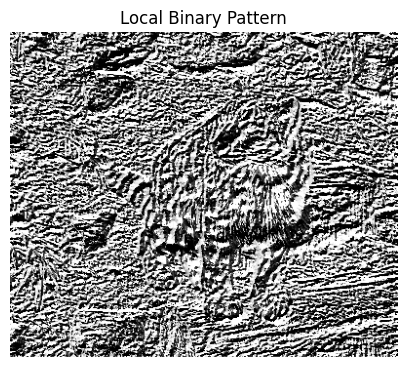

Kernel Size: 5 - Mean: 8367541.78051184, Std: 6903196.603797586, Skewness: 0.008810613206620792, Kurtosis: -1.7104672213574708, Entropy: 2.960626820645998


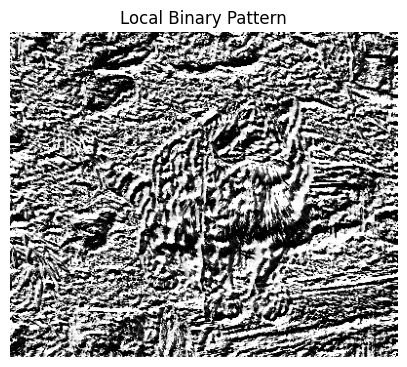

Kernel Size: 7 - Mean: 138487391023197.89, Std: 118866260531677.56, Skewness: 0.03413831411749902, Kurtosis: -1.7492213617677128, Entropy: 1.9756469555793335


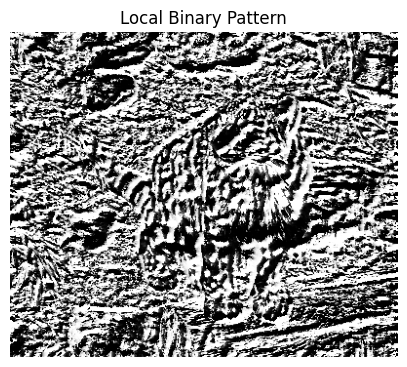

Kernel Size: 9 - Mean: 5.905921349786365e+23, Std: 5.188056535956164e+23, Skewness: 0.04621434847528178, Kurtosis: -1.773592753913188, Entropy: 2.1703322996375194


In [102]:
path = r'Picture1.png'

img_array = np.fromfile(path, dtype=np.uint8)
img = cv2.imdecode(img_array, cv2.IMREAD_COLOR)
grey = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)


plt.figure(figsize=(5, 5))
plt.imshow(grey, cmap='gray')
plt.title("Original Grayscale Image")
plt.axis('off')
plt.show()

for kernel_size in [3, 5, 7, 9]:
    lbp_img = local_binary_pattern(grey, kernel_size=kernel_size)
    plt.figure(figsize=(5, 5))
    plt.imshow(lbp_img, cmap='gray')
    plt.title("Local Binary Pattern")
    plt.axis('off')
    plt.show()

    mean, std, skew1, kurt1, entropy1 = image_statistics(lbp_img)
    print(f"Kernel Size: {kernel_size} - Mean: {mean}, Std: {std}, Skewness: {skew1}, Kurtosis: {kurt1}, Entropy: {entropy1}")

In [103]:
grey.shape

(334, 398)

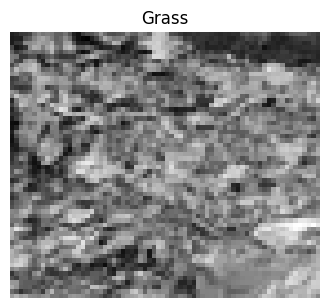

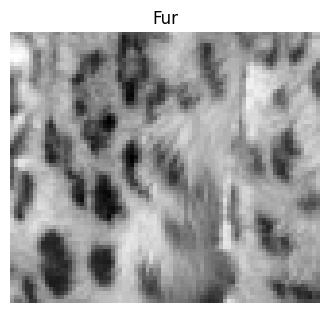

In [121]:
arr = np.array(grey)

grass  = arr[40:100, 130:200]  
fur= arr[150:220, 140:220]

plt.figure(figsize=(4,4))
plt.imshow(grass, cmap='gray')
plt.title("Grass")
plt.axis('off')
plt.show()


plt.figure(figsize=(4,4))
plt.imshow(fur, cmap='gray')
plt.title("Fur")
plt.axis('off')
plt.show()

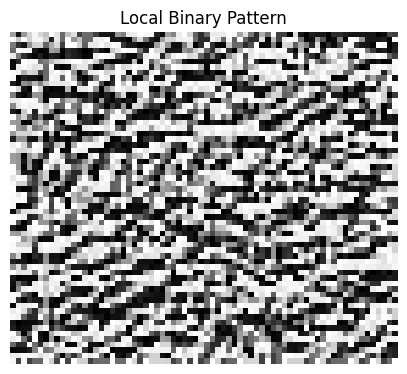

Kernel Size: 3 - Mean: 134.76261904761904, Std: 97.30409418684057, Skewness: -0.10762200118046193, Kurtosis: -1.6360660097906563, Entropy: 4.808736783354854


In [ ]:

lbp_img = local_binary_pattern(grass, kernel_size=3)
plt.figure(figsize=(5, 5))
plt.imshow(lbp_img, cmap='gray')
plt.title("Local Binary Pattern")
plt.axis('off')
plt.show()

mean, std, skew1, kurt1, entropy1 = image_statistics(lbp_img)
print(f"Kernel Size: {3} - Mean: {mean}, Std: {std}, Skewness: {skew1}, Kurtosis: {kurt1}, Entropy: {entropy1}")


lbp_img2 = local_binary_pattern(fur, kernel_size=3)
plt.figure(figsize=(5, 5))
plt.imshow(lbp_img2, cmap='gray')
plt.title("Local Binary Pattern")
plt.axis('off')
plt.show()

mean, std, skew1, kurt1, entropy1 = image_statistics(lbp_img2)
print(f"Kernel Size: {3} - Mean: {mean}, Std: {std}, Skewness: {skew1}, Kurtosis: {kurt1}, Entropy: {entropy1}")

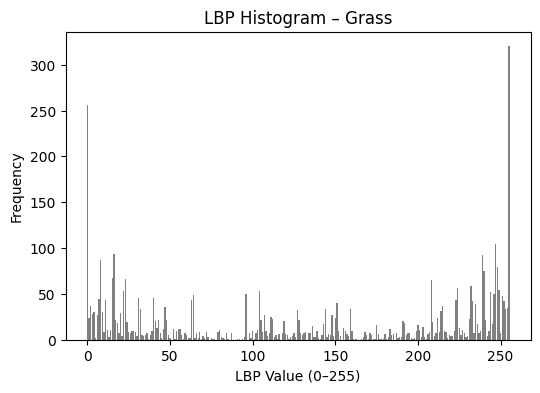

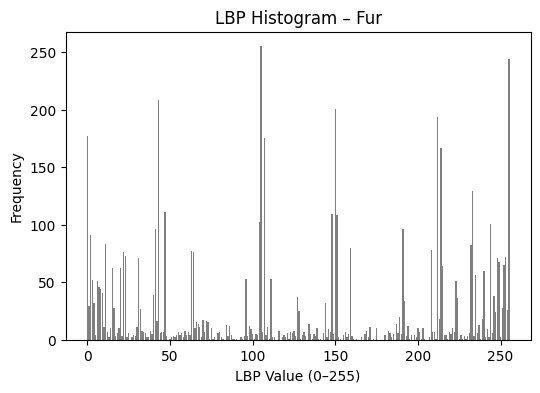

Chi-Square Distance (Grass vs Fur): 1939.9703


In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def lbp_hist(img):
    hist, _ = np.histogram(img.flatten(), bins=256, range=(0, 256))
    return hist


def chi_square_distance(h1, h2):
    h1 = h1.astype(float)
    h2 = h2.astype(float)
    eps = 1e-10
    return np.sum((h1 - h2)**2 / (h1 + h2 + eps))


lbp_grass = local_binary_pattern(grass, kernel_size=3)
lbp_fur   = local_binary_pattern(fur,   kernel_size=3)

hist_grass = lbp_hist(lbp_grass)
hist_fur   = lbp_hist(lbp_fur)



# Grass
plt.figure(figsize=(6, 4))
plt.bar(np.arange(256), hist_grass, color='gray')
plt.title("LBP Histogram – Grass")
plt.xlabel("LBP Value (0–255)")
plt.ylabel("Frequency")
plt.show()

# Fur
plt.figure(figsize=(6, 4))
plt.bar(np.arange(256), hist_fur, color='gray')
plt.title("LBP Histogram – Fur")
plt.xlabel("LBP Value (0–255)")
plt.ylabel("Frequency")
plt.show()

chi_sq = chi_square_distance(hist_grass, hist_fur)
print(f"Chi-Square Distance (Grass vs Fur): {chi_sq:.4f}")
